# Tugas 04 : **Centrality**

NAMA : Mohammad Hasan Basri

NIM  : 210411100169

MATA KULIAH : Pencarian dan Penambangan Web - A

Centrality adalah konsep dalam teori graf yang digunakan untuk mengukur pentingnya suatu simpul (node) dalam sebuah jaringan (graph). Dalam jaringan, simpul-simpul saling terhubung oleh tepi (edges), dan centrality membantu menentukan simpul mana yang paling berpengaruh atau paling "sentral" dalam proses komunikasi, aliran informasi, atau interaksi dalam jaringan tersebut. Ada beberapa jenis centrality yang masing-masing menawarkan cara berbeda untuk menentukan simpul yang penting.

beberapa jenis centrality yang paling umum:

1. Degree Centrality (Sentralitas Derajat) :
*   Mengukur seberapa banyak koneksi langsung yang dimiliki oleh suatu simpul.
*   Semakin banyak koneksi langsung, semakin besar degree centrality simpul tersebut.
*   Contoh: Dalam jaringan sosial, seseorang yang memiliki banyak teman atau kontak langsung akan memiliki degree centrality yang tinggi.

2. Closeness Centrality (Sentralitas Kedekatan) :
*   Mengukur seberapa dekat suatu simpul dengan simpul lain dalam jaringan.
*   Semakin kecil total jarak antara simpul tersebut dengan semua simpul lainnya, semakin tinggi closeness centrality-nya.
*   Contoh: Dalam sebuah jaringan transportasi, simpul yang bisa mencapai simpul lain dengan cepat memiliki closeness centrality yang tinggi.

3. Betweenness Centrality (Sentralitas Keterhubungan) :
*   Mengukur seberapa sering suatu simpul berada di antara jalur terpendek (shortest path) antara dua simpul lainnya.
*   Simpul dengan betweenness centrality tinggi berperan sebagai "jembatan" atau perantara dalam jaringan, yang memungkinkan aliran informasi melalui mereka.
*   Contoh: Dalam sebuah jaringan bisnis, seseorang yang menjadi perantara komunikasi antara dua kelompok mungkin memiliki betweenness centrality yang tinggi.

5. Eigenvector Centrality (Sentralitas Eigenvector):
*   Tidak hanya menghitung berapa banyak koneksi yang dimiliki oleh suatu simpul, tetapi juga seberapa penting koneksi-koneksi tersebut.
*   Simpul yang terhubung dengan simpul penting lainnya akan memiliki eigenvector centrality yang tinggi.
*   Contoh: Dalam jaringan sosial, seseorang yang memiliki koneksi ke orang-orang yang sangat berpengaruh akan memiliki eigenvector centrality yang tinggi.

Centrality digunakan dalam berbagai bidang seperti ilmu sosial, biologi, ekonomi, dan ilmu komputer untuk menganalisis struktur jaringan dan mengidentifikasi simpul kunci yang memiliki pengaruh besar dalam jaringan tersebut.



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import pandas as pd

df = pd.read_excel("/content/drive/My Drive/PPWA/report/Tugas_PPWA/Crawl-berita-Pariwisata&Keislaman.xlsx")
df.head(100)

,judul,tanggal,isi,kategori
0,Iran Serukan Negara Muslim Bersatu Hentikan Ke...,"Kamis, 17 Okt 2024 10:01 WIB",Jakarta - Presiden Iran Masoud Pezeshkian mene...,Keislaman
1,"Bacaan Al-Qur'an Surah Asy-Syu'ara: Arab, Lati...","Kamis, 17 Okt 2024 09:30 WIB",NaN,Keislaman
2,"Rukun Iman Ke-2, Setiap Muslim Wajib Mengimani...","Kamis, 17 Okt 2024 08:45 WIB",Jakarta - Malaikat adalah makhluk ciptaan Alla...,Keislaman
3,Kalender Ramadhan 2025 Muhammadiyah dan Predik...,"Kamis, 17 Okt 2024 08:00 WIB",Jakarta - Kalender Ramadhan 2025 versi Muhamma...,Keislaman
4,20 Gambaran Kehidupan di Neraka Menurut Al-Qur...,"Kamis, 17 Okt 2024 07:15 WIB",Jakarta - Gambaran kehidupan di neraka selalu ...,Keislaman
...,...,...,...,...
95,"Praha Incar Turis-Turis Kaya, 'Wisata Pub Jala...","Rabu, 16 Okt 2024 06:13 WIB",Praha - Praha ingin mengganti imej dari kota s...,Pariwisata
96,"Usai Festival Vegetarian, Phuket Pusing dengan...","Rabu, 16 Okt 2024 05:39 WIB",Phuket - Festival Vegetarian menjadi salah sat...,Pariwisata
97,Ngeri! Turis Inggris Tewas Saat Memanjat Jemba...,"Rabu, 16 Okt 2024 05:01 WIB",Jakarta - Seorang turis yang juga kreator kont...,Pariwisata
98,Info Loker: Lion Group Buka Lowongan Mekanik Nih!,"Selasa, 15 Okt 2024 23:04 WIB",Jakarta - Traveler yang ingin bekerja di dunia...,Pariwisata


In [13]:
# mengambil satu sample berita
sample_berita = df['isi'].iloc[1]
print(sample_berita)


nan


memisahkan per kalimat


---




In [15]:
# mengambil satu sample berita
sample_berita = df['isi'].iloc[1]

# Check if sample_berita is a float (nan) and convert to string if necessary
if isinstance(sample_berita, float):
    sample_berita = str(sample_berita)

print(sample_berita)

# Membuat list untuk menyimpan hasil
result_list = []

# Pisahkan kalimat berdasarkan titik
sentences = sample_berita.split('.')  # Pisahkan kalimat berdasarkan titik
sentences = [s.strip() for s in sentences if s.strip()]  # Hilangkan spasi berlebih dan kosong

# Looping untuk menambahkan setiap kalimat ke result_list
for i, sentence in enumerate(sentences, 1):
    result_list.append({'kalimat ke n': f"Kalimat ke {i}", 'kalimat': sentence})

# Membuat DataFrame dari hasil pemisahan
result_df = pd.DataFrame(result_list)

# Tampilkan DataFrame
result_df

nan


,kalimat ke n,kalimat
0,Kalimat ke 1,nan


pre processing


---



In [16]:
!pip install Sastrawi

In [17]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import nltk
from nltk.tokenize import sent_tokenize
import networkx as nx
import matplotlib.pyplot as plt


# Download stopwords untuk bahasa Indonesia
nltk.download('stopwords')
stop_words = stopwords.words('indonesian')

# Fungsi preprocessing yang disesuaikan
def remove_url(data_berita):
    url = re.compile(r'https?://\S+|www\.S+')
    return url.sub(r'', data_berita)

def remove_html(data_berita):
    html = re.compile(r'<.#?>')
    return html.sub(r'', data_berita)

def remove_emoji(data_berita):
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticon
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', data_berita)

def remove_numbers(data_berita):
    data_berita = re.sub(r'\d+', '', data_berita)
    return data_berita

def remove_symbols(data_berita):
    data_berita = re.sub(r'[^a-zA-Z0-9\s]', '', data_berita)
    return data_berita

def case_folding(text):
    if isinstance(text, str):
        return text.lower()
    return text

def tokenize(text):
    return text.split()

def remove_stopwords(text):
    return [word for word in text if word not in stop_words]

# Inisialisasi stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(text):
    return [stemmer.stem(word) for word in text]

# Looping setiap kalimat di dataframe 'result_df'
result_df['clean'] = result_df['kalimat'].apply(remove_url)
result_df['clean'] = result_df['clean'].apply(remove_html)
result_df['clean'] = result_df['clean'].apply(remove_emoji)
result_df['clean'] = result_df['clean'].apply(remove_symbols)
result_df['clean'] = result_df['clean'].apply(remove_numbers)
result_df['clean'] = result_df['clean'].apply(case_folding)
result_df['tokenize'] = result_df['clean'].apply(tokenize)
result_df['stopword removal'] = result_df['tokenize'].apply(remove_stopwords)
result_df['stemming'] = result_df['stopword removal'].apply(stemming)

# Gabungkan kata setelah stemming
result_df['final'] = result_df['stemming'].apply(lambda x: ' '.join(x))

# Tampilkan hasil dataframe
result_df[['kalimat ke n', 'final']]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,kalimat ke n,final
0,Kalimat ke 1,nan


TF-IDF


---

menghitung skor **TF-IDF (Term Frequency-Inverse Document Frequency)** dari setiap kata dalam kalimat yang telah diproses untuk menilai seberapa penting kata-kata tersebut dalam konteks kalimat. Pertama, kalimat-kalimat digabung menjadi dokumen, kemudian TF-IDF diterapkan untuk menghasilkan matriks yang menunjukkan skor setiap kata dalam setiap kalimat. Nama-nama kata (fitur) diambil dan hasil TF-IDF ini diubah menjadi tabel agar lebih mudah dianalisis. Selanjutnya, ditambahkan kolom identifikasi untuk setiap kalimat, dan akhirnya tabel tersebut ditampilkan dengan menampilkan skor TF-IDF dari kata-kata di setiap kalimat.

In [18]:
# Gabungkan semua kalimat hasil stemming menjadi dokumen untuk tiap kalimat
documents = result_df['final'].tolist()

# Inisialisasi TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer()

# Terapkan TF-IDF ke dokumen (kalimat yang sudah dipreproses)
tfidf_matrix = tfidf_vectorizer.fit_transform(documents)

# Mendapatkan nama-nama fitur (kata-kata)
feature_names = tfidf_vectorizer.get_feature_names_out()

# Mengubah hasil TF-IDF menjadi dataframe
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

# Tambahkan kolom 'no' dan 'kalimat ke n' untuk identifikasi
tfidf_df.insert(0, 'kalimat ke n', result_df['kalimat ke n'])

# Tampilkan dataframe dengan skor TF-IDF
tfidf_df

,kalimat ke n,nan
0,Kalimat ke 1,1.0


**Menghitung kemiripan antar kalimat**


---


Kalimat-kalimat dalam kumpulan teks yang telah diubah menjadi angka menggunakan TF-IDF, dan kemudian dihitung cosine similarity-nya. Nilai cosine similarity ini menunjukkan seberapa mirip dua kalimat. Jika angkanya mendekati 1, berarti dua kalimat sangat mirip, sedangkan jika mendekati 0, berarti tidak mirip.

In [19]:
# Menghitung cosine similarity antar kalimat berdasarkan TF-IDF
cosine_sim = cosine_similarity(tfidf_matrix)

# Membuat dataframe untuk menyimpan hasil cosine similarity
cosine_sim_df = pd.DataFrame(cosine_sim, index=result_df['kalimat ke n'], columns=result_df['kalimat ke n'])

# Tampilkan matriks cosine similarity
cosine_sim_df

kalimat ke n,Kalimat ke 1
kalimat ke n,
Kalimat ke 1,1.0


**Membuat matriks adjacency berdasarkan nilai ambang batas**

---



membuat **matriks adjacency** berdasarkan nilai **cosine similarity** antar kalimat. Pertama, ambang batas (**threshold**) ditetapkan pada 0,5, yang berarti bahwa jika nilai cosine similarity antara dua kalimat sama dengan atau lebih besar dari 0,5, maka akan diberi nilai 1 (menunjukkan adanya keterkaitan antara kalimat); jika lebih kecil dari itu, diberi nilai 0 (tidak ada keterkaitan). Hasil ini disimpan dalam sebuah matriks adjacency, yang kemudian diubah menjadi **dataframe** untuk menampilkan hasilnya secara lebih jelas dengan baris dan kolom yang mewakili setiap kalimat.

In [20]:
# Tetapkan ambang batas (threshold) 0.5
threshold = 0.4

# Buat matriks adjacency: jika cosine similarity >= 0.5, maka 1; jika tidak, maka 0
adjacency_matrix = np.where(cosine_sim >= threshold, 1, 0)

# Buat dataframe untuk menampilkan matriks adjacency
adjacency_df = pd.DataFrame(adjacency_matrix, index=result_df['kalimat ke n'], columns=result_df['kalimat ke n'])

# Tampilkan matriks adjacency
adjacency_df

kalimat ke n,Kalimat ke 1
kalimat ke n,
Kalimat ke 1,1


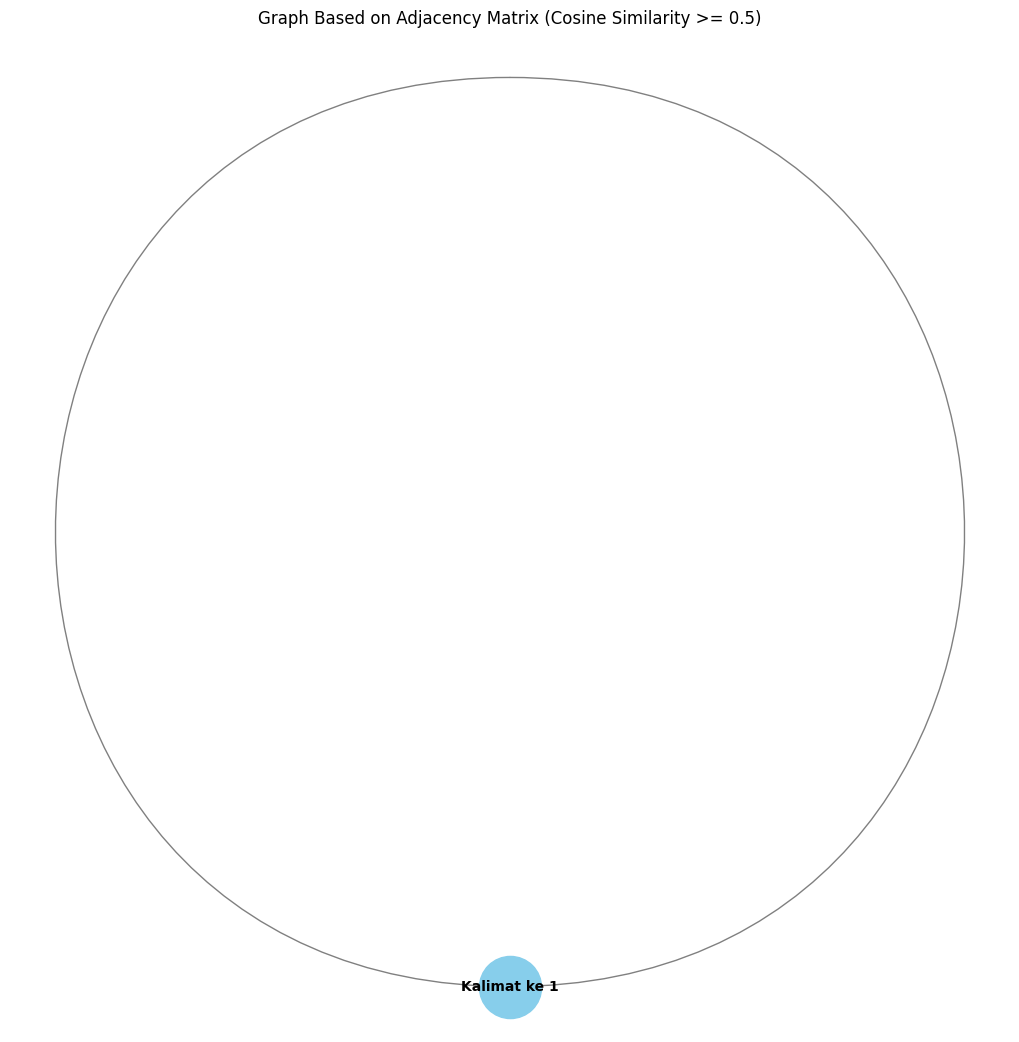

In [21]:
# Buat graf dari matriks adjacency
G = nx.from_numpy_array(adjacency_matrix)

# Atur label node agar sesuai dengan 'kalimat ke n'
mapping = {i: f"Kalimat ke {i+1}" for i in range(len(result_df))}
G = nx.relabel_nodes(G, mapping)

# Menggambar graf
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G)  # Atur layout graf
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=2000, font_size=10, font_color='black', edge_color='gray', linewidths=1, font_weight='bold')

# Tampilkan graf
plt.title("Graph Based on Adjacency Matrix (Cosine Similarity >= 0.5)")
plt.show()

In [22]:
# Menghitung betweenness centrality
betweenness_centrality = nx.betweenness_centrality(G)

# Menghitung degree centrality
degree_centrality = nx.degree_centrality(G)

# Menghitung closeness centrality
closeness_centrality = nx.closeness_centrality(G)

# Buat dataframe untuk menampilkan hasil centrality
centrality_df = pd.DataFrame({
    'Kalimat': list(betweenness_centrality.keys()),
    'Betweenness Centrality': list(betweenness_centrality.values()),
    'Degree Centrality': list(degree_centrality.values()),
    'Closeness Centrality': list(closeness_centrality.values())
})

# Tampilkan dataframe centrality
centrality_df


,Kalimat,Betweenness Centrality,Degree Centrality,Closeness Centrality
0,Kalimat ke 1,0.0,1,0.0
